# Factor Analysis

## Objective

The objective of this notebook is to analyze the temporal evolution of the latent statistical factors identified trough Principal Component Analysis (PCA).

Instead of estimating a single PCA over the entire sample, a rolling window approach is employed so that the factor structure is estimated using only information available up to each point in time. This allows us to study how the dominant factors, their importance, and their exposure evolve through time.

The resulting time-varying factors will constitute the basis for the feature engineering and trading strategy developed in the following notebook.

The computations are based on the following:

For t = W,..., N:

 1. Extract the window [t-W+1, t]
 2. Adjust PCA
 3. Store:
     - Explained variance ratio (on the window)
     - Loadings
     - Last day score

Observe that all the information before t is used, this makes look-ahead bias less probable.

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

In [45]:
# Data loading 
eurusd = pd.read_csv("../data/raw/EURUSD.csv")
gbpusd = pd.read_csv("../data/raw/GBPUSD.csv")

# Dates need to be aligned
eurusd["date"] = pd.to_datetime(eurusd["date"])
gbpusd["date"] = pd.to_datetime(gbpusd["date"])


eurusd_clean = eurusd[["date", "close"]].rename(
    columns={"close": "EURUSD"}
)

gbpusd_clean = gbpusd[["date", "close"]].rename(
    columns={"close": "GBPUSD"}
)


prices = pd.merge(
    eurusd_clean,
    gbpusd_clean,
    on="date",
    how="inner"
)


prices = prices.sort_values("date").set_index("date")

In [46]:
def rolling_pca(returns, window=126):

    """
    Performs a rolling Principal Component Analysis (PCA).

    Parameters
    ----------

    data: pandas.DataFrame
        DataFrame containing the asset returns.
        Rows correspond to dates and columns to assets

    window: int, default=126
        Rolling window size

    Returns
    -------
    pandas.DataFrame
        DataFrame containing the rolling PCA results
    """
    
    dates = []
    
    explained_variance_ratio_1 = []
    explained_variance_ratio_2 = []
    
    pc1_eur = []
    pc1_gbp = []
    
    pc2_eur = []
    pc2_gbp = []
    
    pc1_score = []
    pc2_score = []
    
    previous_components = None
    
    for t in range(window, len(returns) + 1):
    
        # Rolling window
        window_returns = returns.iloc[t-window:t]
    
        # Fit the PCA to the returns window
        pca = PCA(n_components=2)
        pca.fit(window_returns)
        components = pca.components_.copy()
    
        # Be careful with the sign of the returned eigenvector
        if previous_components is not None:
            for i in range(components.shape[0]):
                if np.dot(components[i], previous_components[i]) < 0:
                    components[i] *= -1
    
        # Compute the scores
        # Note here that we need to compute the scores dependent on the orientation
        # and not dependent with the original returned by scikit-learn
        scores = window_returns.values @ components.T
    
        # Store the components for the next iteration
        previous_components = components.copy()
    
        # Date of the window last day
        dates.append(window_returns.index[-1])
    
        # Store the explained variance ratio
        explained_variance_ratio_1.append(pca.explained_variance_ratio_[0])
        explained_variance_ratio_2.append(pca.explained_variance_ratio_[1])
    
        # Store the loadings
        pc1_eur.append(components[0, 0])
        pc1_gbp.append(components[0, 1])
    
        pc2_eur.append(components[1, 0])
        pc2_gbp.append(components[1, 1])
    
        # Store the score of the last day of the window
        pc1_score.append(scores[-1, 0])
        pc2_score.append(scores[-1, 1])

        results = pd.DataFrame({
            "PC1_loading_EURUSD": pc1_eur,
            "PC1_loading_GBPUSD": pc1_gbp,
            "PC2_loading_EURUSD": pc2_eur,
            "PC2_loading_GBPUSD": pc2_gbp,
            "EVR1": explained_variance_ratio_1,
            "EVR2": explained_variance_ratio_2,
            "PC1_score": pc1_score,
            "PC2_score": pc2_score,
        }, index=dates)

        results.index.name = "Date"
    return results

In [47]:
rolling_results = rolling_pca(returns, window=126)

## Analysis

### Explained variance ratio evolution

<Axes: title={'center': 'Rolling Explained Variance Ratio - PC1'}, xlabel='Time [days]', ylabel='Explained Variance'>

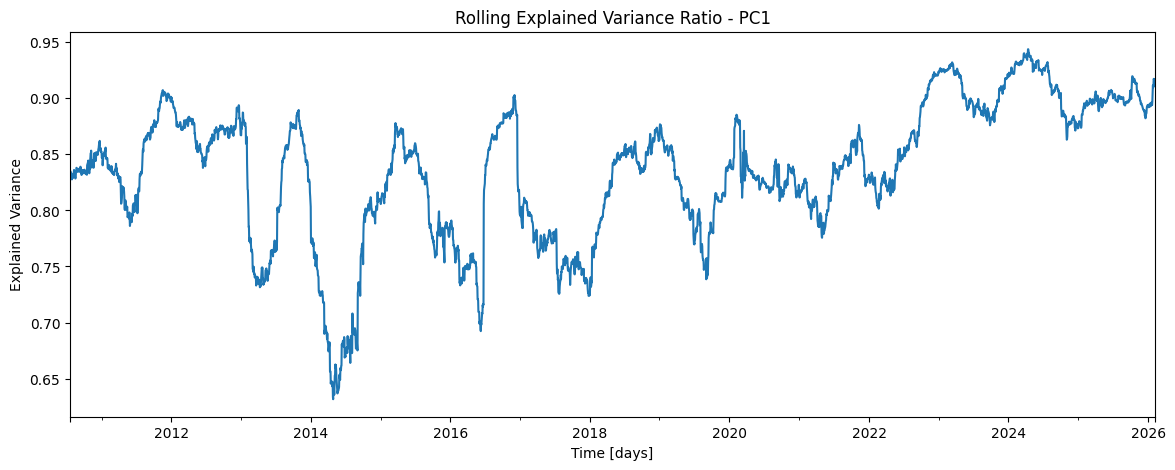

In [48]:
rolling_results["EVR1"].plot(figsize=(14, 5), title="Rolling Explained Variance Ratio - PC1", xlabel="Time [days]", ylabel="Explained Variance");

<Axes: title={'center': 'Rolling Explained Variance Ratio - PC2'}, xlabel='Time [days]', ylabel='Explained Variance'>

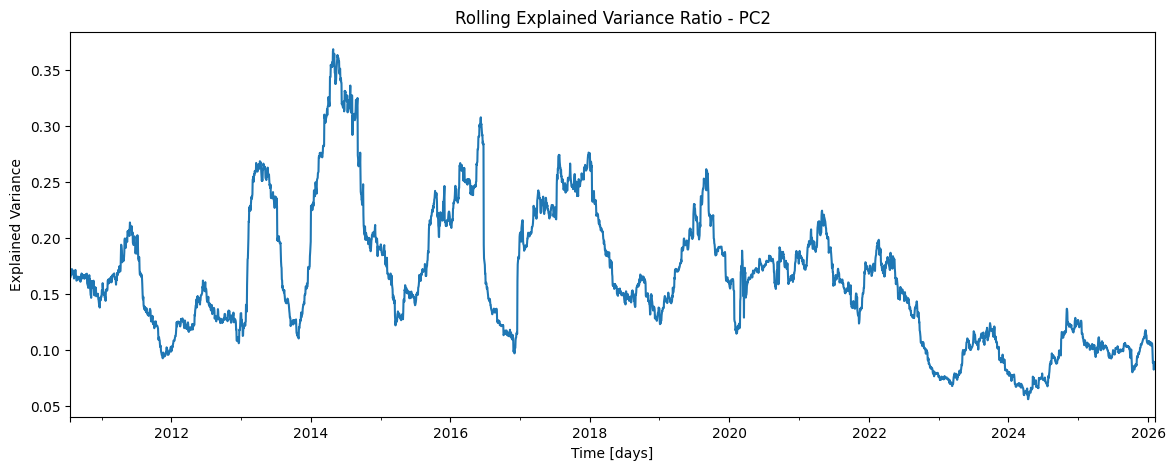

In [49]:
rolling_results["EVR2"].plot(figsize=(14, 5), title="Rolling Explained Variance Ratio - PC2", xlabel="Time [days]", ylabel="Explained Variance");

Both of the graphics above shows a complementary movemente in the explained variance ratio of the two principal components, this means when one component explains less variance, the other explains greater variance automatically, PC1 isn't above 80% always, in fact, later in 2014 shows a reduction in explained variance and PC2 shows an increment in this one.

### Rolling Loadings

<Axes: title={'center': 'PC1 Loadings vs Time'}, xlabel='Time [days]', ylabel='Loadings'>

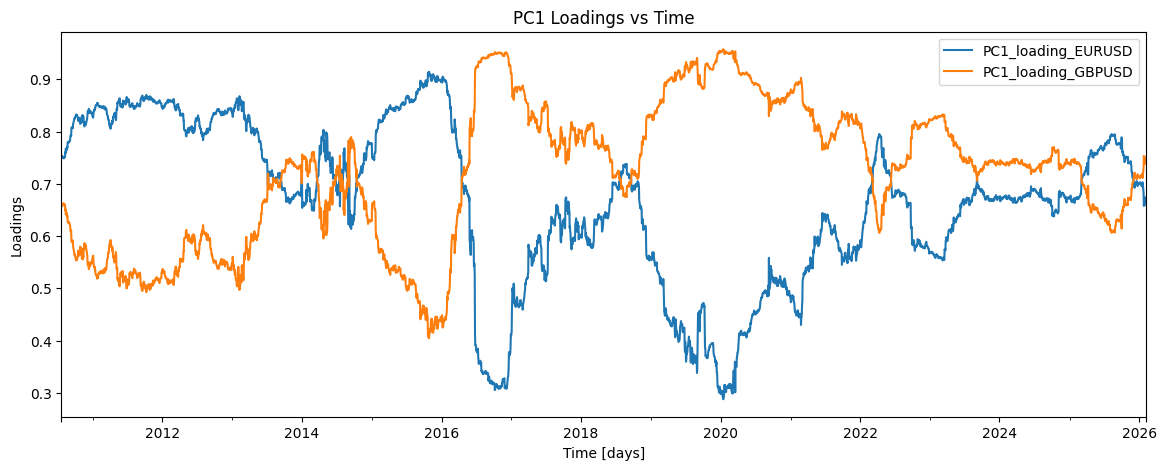

In [50]:
rolling_results[["PC1_loading_EURUSD", "PC1_loading_GBPUSD"]].plot(
    figsize=(14, 5),
    xlabel="Time [days]",
    ylabel="Loadings",
    title="PC1 Loadings vs Time"
);

<Axes: title={'center': 'PC2 Loadings vs Time'}, xlabel='Time [days]', ylabel='Loadings'>

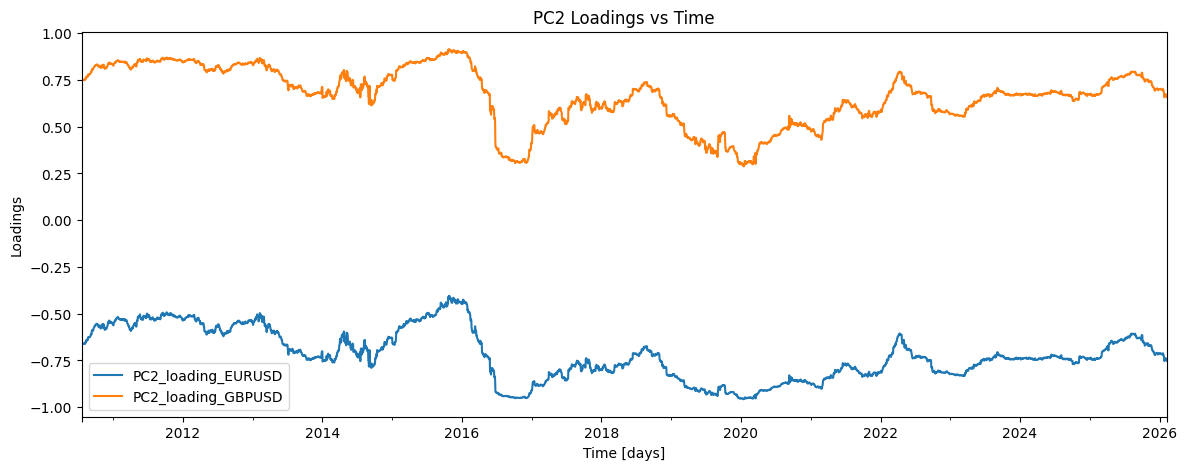

In [51]:
rolling_results[["PC2_loading_EURUSD", "PC2_loading_GBPUSD"]].plot(
    figsize=(14, 5),
    xlabel="Time [days]",
    ylabel="Loadings",
    title="PC2 Loadings vs Time"
);

It can be seen the complementary movement of the loadings of PC1, the magnitude of the change in this loadings are expected to be greater than the magnitude of the change of the second principal component, this fit perfectly because PC1 explained a greater variance ratio.

### Rolling Scores

<Axes: title={'center': 'PC1 Score vs Time'}, xlabel='Time [days]', ylabel='PC1 Score'>

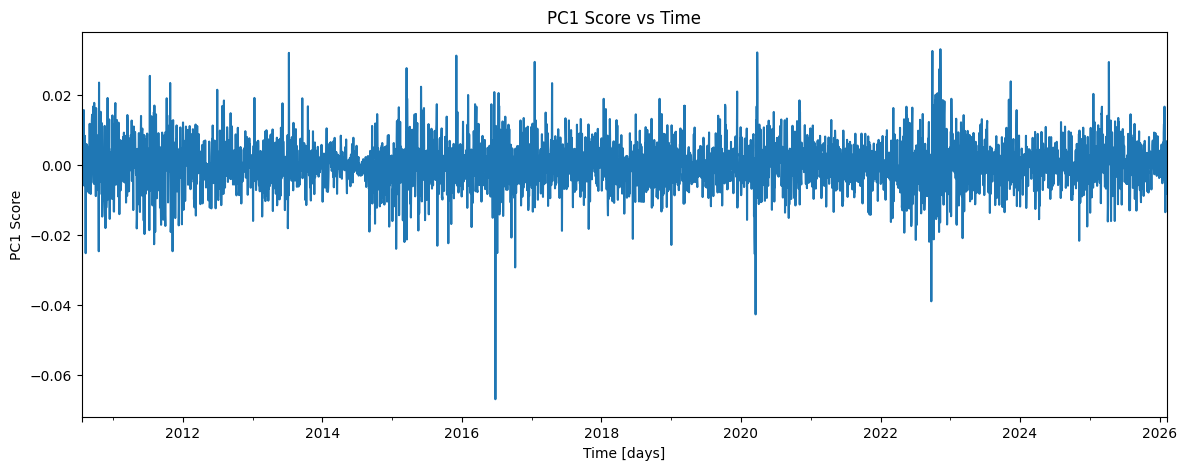

In [52]:
rolling_results["PC1_score"].plot(
    figsize=(14, 5),
    xlabel="Time [days]",
    ylabel="PC1 Score",
    title="PC1 Score vs Time"
);

<Axes: title={'center': 'PC2 Score vs Time'}, xlabel='Time [days]', ylabel='PC2 Score'>

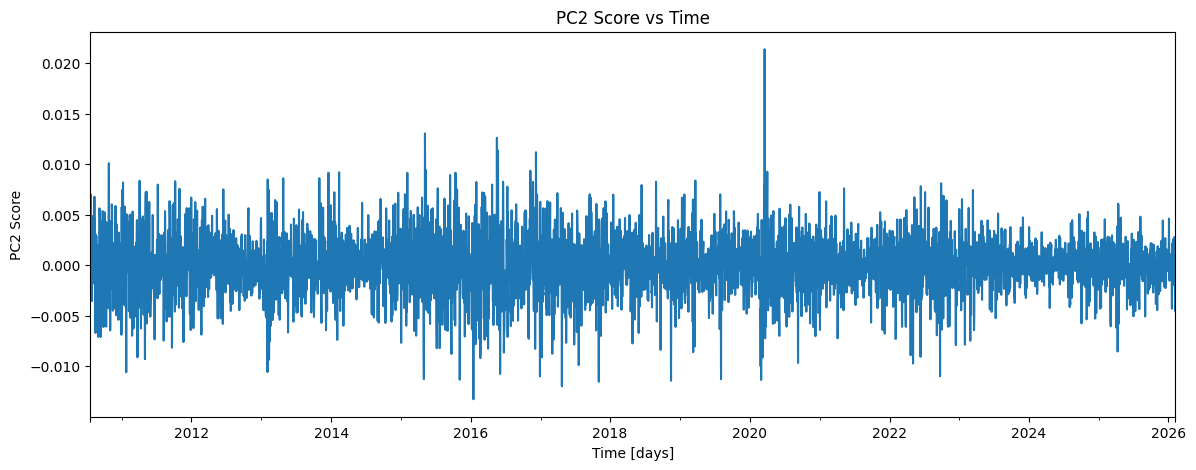

In [53]:
rolling_results["PC2_score"].plot(
    figsize=(14, 5),
    xlabel="Time [days]",
    ylabel="PC2 Score",
    title="PC2 Score vs Time"
);

In [54]:
rolling_results.describe().loc["mean"]

PC1_loading_EURUSD    0.664065
PC1_loading_GBPUSD    0.719937
PC2_loading_EURUSD   -0.719937
PC2_loading_GBPUSD    0.664065
EVR1                  0.835746
EVR2                  0.164254
PC1_score            -0.000035
PC2_score            -0.000008
Name: mean, dtype: float64

The mean of the loadings corresponding to the first principal component are positive, and the mean explained variance ratio for the first principal component is above 80%

<Axes: >

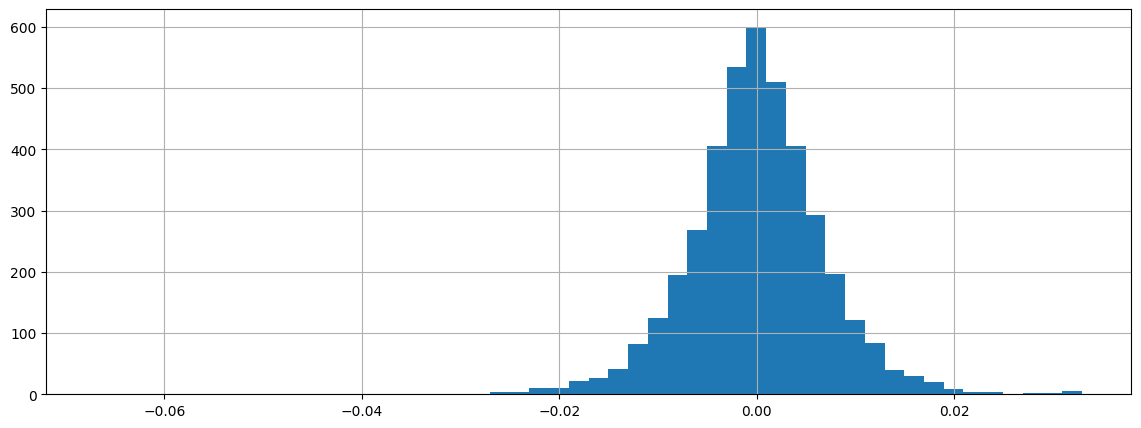

In [55]:
rolling_results["PC1_score"].hist(bins=50, figsize=(14, 5));

<Axes: >

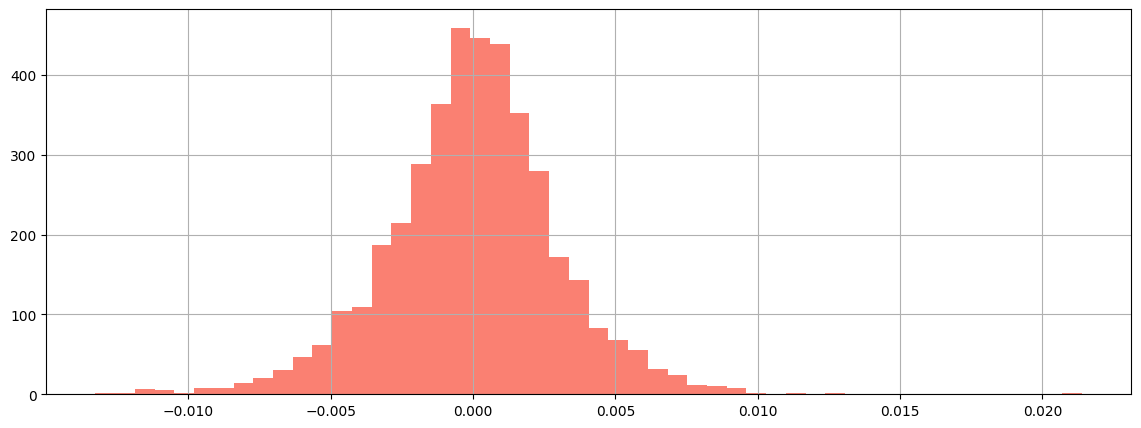

In [56]:
rolling_results["PC2_score"].hist(bins=50, figsize=(14, 5), color="salmon");

The scores of the principal component appears to be symmetric as it was shown in the previous notebook, suggesting that empirical distributions are close to a Gaussian distribution.

### Correlation between scores

<Axes: >

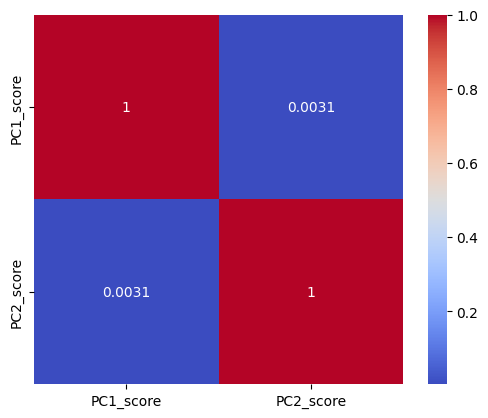

In [57]:
sns.heatmap(rolling_results[["PC1_score", "PC2_score"]].corr(),annot=True, cmap="coolwarm", square=True);

It was expected for this correlations to be close to zero due to each component captures different sources of variations.

**The rolling PCA reveals a stable latent factor structure in the FX market, the first principal component consistently explains most of the joint variability of EUR/USD and GBP/USD, suggesting the presence of a dominant common factor. The second component captures relative deviations between the two exchanges rates, since the associated scores are nearly uncorrelated, both components provide complementary information that may be useful for predicting future market movements.**

### Relationship between Factors and Future Returns

In [61]:
target = returns["EURUSD"].shift(-1).rename("target")
dataset = rolling_results.join(target, how="inner")
dataset = dataset.dropna()
dataset.head()

,PC1_loading_EURUSD,PC1_loading_GBPUSD,PC2_loading_EURUSD,PC2_loading_GBPUSD,EVR1,EVR2,PC1_score,PC2_score,target
2010-07-21,0.751244,0.660025,-0.660025,0.751244,0.832474,0.167526,-0.013030,0.002362,0.011882
2010-07-22,0.754137,0.656718,-0.656718,0.754137,0.835203,0.164797,0.013228,-0.002902,-0.000279
2010-07-23,0.750533,0.660833,-0.660833,0.750533,0.832769,0.167231,0.005795,0.007004,0.005748
2010-07-26,0.753160,0.657838,-0.657838,0.753160,0.832206,0.167794,0.006692,-0.001076,0.000447
2010-07-27,0.750752,0.660584,-0.660584,0.750752,0.832823,0.167177,0.004738,0.004708,0.000662


In [63]:
dataset["PC1_decile"] = pd.qcut(
    dataset["PC1_score"],
    q=10,
    labels=False
)

quantile_analysis = (
    dataset
    .groupby("PC1_decile")["target"]
    .mean()
)

quantile_analysis

PC1_decile
0   -0.000118
1    0.000158
2    0.000038
3    0.000232
4    0.000338
5   -0.000419
6   -0.000106
7    0.000024
8   -0.000059
9   -0.000280
Name: target, dtype: float64

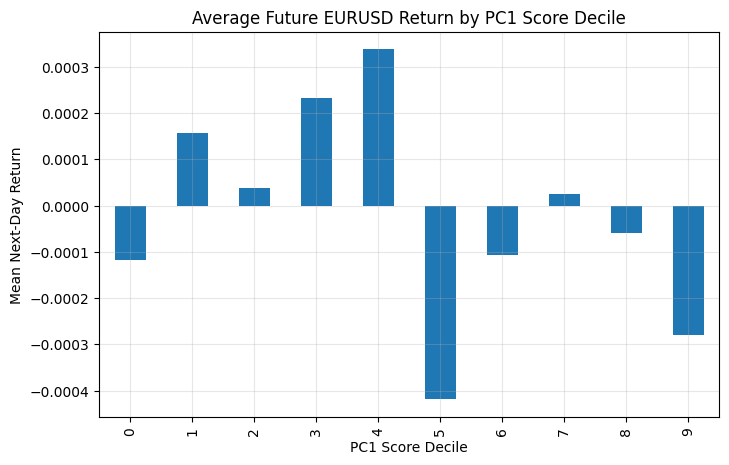

In [64]:
plt.figure(figsize=(8, 5))
quantile_analysis.plot(kind="bar")

plt.title("Average Future EURUSD Return by PC1 Score Decile")
plt.xlabel("PC1 Score Decile")
plt.ylabel("Mean Next-Day Return")

plt.grid(alpha=0.3)
plt.show()